# Combined  model
In this script we:
- extract predicted probability
- average predicted probabilities
- evaluate the combined model

In [1]:
# Training Model OB1+OB2 data
# Import modules
import pandas as pd
from math import sqrt
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
import sklearn.impute
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import seaborn as sb
import statistics
import seaborn as sn
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import sklearn.ensemble
from statistics import mean
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import pandas as pd
import scipy.stats as stats
import os

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.feature_selection import SelectKBest, f_classif, RFE

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# from sksurv.linear_model import CoxnetSurvivalAnalysis
# from sksurv.metrics import concordance_index_censored
# from sksurv.util import Surv
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

/Users/sarahgalante/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

## Loading images train data

In [ ]:
#@title Set the path
train_path=r''
output_path = ''
if not os.path.exists(output_path): #create folder if it doesn't exist
    os.makedirs(output_path)

train_failed=os.path.join(train_path,'classe_1')
train_notfal=os.path.join(train_path,'classe_0')
print(len(os.listdir(train_failed)))
print(len(os.listdir(train_notfal)))

801
785


In [297]:
SEED = 4224
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [298]:
AP_image = os.path.join(train_notfal,'O1-A-0279-1m L.jpg')
LAT_image = os.path.join(train_notfal,'O1-A-0279-1m AP.jpg')

es_AP = load_img(AP_image,target_size=(224,224))
es_LAT = load_img(LAT_image,target_size=(224,224))

In [299]:
#@title Extract the files

fal_names = []
fal_code = []
nonfal_names = []
nonfal_code = []

for sample in os.listdir(train_failed):
    fal_code.append(sample.split('_')[0]) #in order to read only the unique code of the signal
    sample_name = os.path.join(train_failed, sample)
    fal_names.append(sample_name)

for sample in os.listdir(train_notfal):
    nonfal_code.append(sample.split('_')[0])
    sample_name = os.path.join(train_notfal, sample)
    nonfal_names.append(sample_name)

In [300]:
#@title We create a dataframe to organize the data and their labels

labels_df=pd.DataFrame(columns=['img','label'])


In [301]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Creiamo un DataFrame per organizzare immagini e label
labels_df = pd.DataFrame(columns=['img', 'label'])

# Popoliamo il DataFrame con le immagini e le label
i = 0
for name in fal_names:
    labels_df.loc[i] = pd.Series({'img': name, 'label': 'failed'})
    i += 1
for nf_name in nonfal_names:
    labels_df.loc[i] = pd.Series({'img': nf_name, 'label': 'not_failed'})
    i += 1

# Estrai gli ID paziente
labels_df['patient_id'] = labels_df['img'].str.extract(r'(O[1]-A-\d{4})')

# Raggruppiamo le label per paziente (tenendo conto di AP e LAT)
patient_labels = labels_df.groupby('patient_id')['label'].apply(lambda x: tuple(x))

# Ottenere gli ID unici dei pazienti
unique_patient_ids = patient_labels.index

In [302]:
unique_patient_ids

Index(['O1-A-0001', 'O1-A-0002', 'O1-A-0003', 'O1-A-0004', 'O1-A-0005',
       'O1-A-0006', 'O1-A-0007', 'O1-A-0008', 'O1-A-0009', 'O1-A-0010',
       ...
       'O1-A-0391', 'O1-A-0392', 'O1-A-0393', 'O1-A-0394', 'O1-A-0395',
       'O1-A-0396', 'O1-A-0397', 'O1-A-0398', 'O1-A-0399', 'O1-A-0400'],
      dtype='object', name='patient_id', length=399)

In [303]:
from sklearn.model_selection import train_test_split

# Conta il numero di immagini failed per paziente
patient_label_counts = labels_df.groupby('patient_id')['label'].value_counts().unstack(fill_value=0)

# Se manca una colonna (es. nessun "failed" in tutto il dataset), la aggiungo per sicurezza
for label in ['failed', 'not_failed']:
    if label not in patient_label_counts.columns:
        patient_label_counts[label] = 0

# Calcolo una "etichetta" sintetica per paziente = label con più immagini
patient_label_counts['majority_label'] = patient_label_counts[['failed', 'not_failed']].idxmax(axis=1)

# Ora possiamo fare stratificazione sui pazienti in base alla label dominante
train_patient_ids, test_patient_ids = train_test_split(
    patient_label_counts.index,
    test_size=0.2,
    stratify=patient_label_counts['majority_label'],
    random_state=42
)

# Assegna train/test nel dataframe
labels_df['split'] = labels_df['patient_id'].apply(
    lambda x: 'train' if x in train_patient_ids else 'test'
)


In [304]:
# Filtra i dati di training
train_df = labels_df[labels_df['split'] == 'train']
unique_train_ids = train_df['patient_id'].unique()

# Conta le label per ogni paziente nel train
patient_label_counts_train = train_df.groupby('patient_id')['label'].value_counts().unstack(fill_value=0)

In [305]:
for label in ['failed', 'not_failed']:
    if label not in patient_label_counts_train.columns:
        patient_label_counts_train[label] = 0

# Determina la label dominante per ogni paziente
patient_label_counts_train['majority_label'] = patient_label_counts_train[['failed', 'not_failed']].idxmax(axis=1)

In [306]:
# Esegui lo split tra train e validation
train_patient_ids, val_patient_ids = train_test_split(
    patient_label_counts_train.index,
    test_size=0.2,
    stratify=patient_label_counts_train['majority_label'],
    random_state=42
)

# Assegna la split solo ai pazienti originariamente in train
labels_df['split'] = labels_df.apply(
    lambda row: 'val' if row['patient_id'] in val_patient_ids else (
        'train' if row['patient_id'] in train_patient_ids else row['split']
    ),
    axis=1
)

In [307]:
# Conta il numero di immagini failed e not_failed per ogni split
split_counts = labels_df.groupby(['split', 'label']).size().unstack(fill_value=0)

# Stampa il risultato
print(split_counts)


label  failed  not_failed
split                    
test      170         150
train     511         500
val       120         135


### Adapting Data to transfer learning model

In [308]:
import os
import random
import numpy as np
import tensorflow as tf

seed = 4224
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


In [309]:
from tensorflow.keras import backend as K
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [310]:
# Creiamo i DataFrame per train, val e test
learning_df = labels_df[labels_df['split'] == 'train']
val_df = labels_df[labels_df['split'] == 'val']
test_df = labels_df[labels_df['split'] == 'test']

In [311]:
val_df['patient_id'] = val_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
learning_df['patient_id'] = learning_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
test_df['patient_id'] = test_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))


/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/3723245249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['patient_id'] = val_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/3723245249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learning_df['patient_id'] = learning_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/3723245249.py:3: SettingWithCopyWarnin

### Preprocessing Images

In [312]:
# Funzione per caricare e preprocessare le immagini
def load_and_preprocess_images(df):
    data_img = []
    valid_paths = []
    
    for img_path in df['img']:
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = tf.keras.applications.densenet.preprocess_input(img_array)
            data_img.append(img_array)
            valid_paths.append(img_path)  # Salva i path validi
        except Exception as e:
            print(f"[SKIPPED] Immagine non valida: {img_path} -> {e}")
    
    return np.array(data_img), valid_paths

# Carichiamo le immagini per ogni set
x_train, valid_train_paths = load_and_preprocess_images(learning_df)
x_val, valid_val_paths = load_and_preprocess_images(val_df)
x_test, valid_test_paths = load_and_preprocess_images(test_df)

# Se vuoi aggiornare i DataFrame per riflettere solo i file validi:
learning_df = learning_df[learning_df['img'].isin(valid_train_paths)].reset_index(drop=True)
val_df = val_df[val_df['img'].isin(valid_val_paths)].reset_index(drop=True)
test_df = test_df[test_df['img'].isin(valid_test_paths)].reset_index(drop=True)

# Controlliamo le shape delle immagini caricate
print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"x_test shape: {x_test.shape}")




x_train shape: (1011, 224, 224, 3)
x_val shape: (255, 224, 224, 3)
x_test shape: (320, 224, 224, 3)


In [313]:
labels=learning_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
train_labels = le.transform(labels)
y_train=to_categorical(train_labels,2)
y_train[:10],learning_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0    /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0230-3m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0291-12m L.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0258-12m L.jpg   
 3    /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIM

In [314]:
labels_val=val_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
val_labels = le.transform(labels_val)
y_val=to_categorical(val_labels,2)
y_val[:10],val_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0385-6m AP.jpg   
 1  /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0094-12m AP.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0161-1m AP.jpg   
 3   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI

In [315]:
labels_test=test_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
test_labels = le.transform(labels_test)
y_test=to_categorical(test_labels,2)
y_test[:10],test_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0128-12m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0100-6m AP.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0222-12m L.jpg   
 3   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI

In [316]:
#@title Set index failed
if y_train[4,0] == 1:
  fail_pos = 0 #index where the failed label is positive
else:
  fail_pos = 1

In [317]:
fail_pos

0

## Loading clinical features training

In [ ]:
main_path = os.getcwd()
# Import data
features = pd.read_excel('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/PRIN_comorbidità+HHS_400.xlsx')

# Display features table
#display(features)

In [ ]:
features = features.rename(columns={"ID STUDIO": "patient_id"})
features['dolore'] = features['dolore'].map({'assente': 0, 'si': 1})
features['Rx features patologiche'] = features['Rx features patologiche'].map({1: 'failed', 0: 'not_failed'})

#features = features.drop(columns=['Rx features patologiche'])
features = features.rename(columns={'Rx features patologiche': 'label'})

In [ ]:
features = features.fillna(0)

In [ ]:
learning_df_merged = pd.merge(learning_df, features, on=['patient_id', 'label'], how='left')
val_df_merged = pd.merge(val_df, features, on=['patient_id', 'label'], how='left')
test_df_merged = pd.merge(test_df, features, on=['patient_id', 'label'], how='left')


In [ ]:
learning_df_merged_unique = learning_df_merged.drop_duplicates(subset='patient_id', keep='first')
val_df_merged_unique = val_df_merged.drop_duplicates(subset='patient_id', keep='first')
test_df_merged_unique = test_df_merged.drop_duplicates(subset='patient_id', keep='first')


In [ ]:
# Scelgiere features da mantenere nel modello HHS
X_train_w = learning_df_merged_unique.iloc[:,[4,5,7,8,9,10]]
X_val_w = val_df_merged_unique.iloc[:,[4,5,7,8,9,10]]
X_test_w = test_df_merged_unique.iloc[:,[4,5,7,8,9,10]]

y_train_w=learning_df_merged_unique.iloc[:,[1]]
y_val_w=val_df_merged_unique.iloc[:,[1]]
y_test_w=test_df_merged_unique.iloc[:,[1]]

In [ ]:
len(X_val_w)

128

In [ ]:
y_train_w['label'] = y_train_w['label'].map({'failed':1, 'not_failed':0})
y_val_w['label'] = y_val_w['label'].map({'failed':1, 'not_failed':0})
y_test_w['label'] = y_test_w['label'].map({'failed':1, 'not_failed':0})

/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/1897539489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train_w['label'] = y_train_w['label'].map({'failed':1, 'not_failed':0})
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/1897539489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_val_w['label'] = y_val_w['label'].map({'failed':1, 'not_failed':0})
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/1897539489.py:3: SettingWithCopyWarning: 
A value 

In [ ]:
y_train_w = y_train_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
y_val_w = y_val_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
y_test_w = y_test_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna

In [ ]:
from sklearn.preprocessing import StandardScaler

# Definisci le colonne numeriche (quelle che vuoi scalare)
numeric_cols = ['peso (kg)','altezza (cm)']

# Colonne categoriche (che NON vanno scalate)
categorical_cols = [col for col in X_train_w.columns if col not in numeric_cols and col != 'dolore']
# Inizializza lo scaler
scaler = StandardScaler()
# Training: fit e transform sulle colonne selezionate
scaled_train = scaler.fit_transform(X_train_w[numeric_cols])
data_train_scaled = X_train_w.copy()
data_train_scaled[numeric_cols] = scaled_train

# Validation: trasformazione usando scaler già fit
scaled_val = scaler.transform(X_val_w[numeric_cols])
data_val_scaled = X_val_w.copy()
data_val_scaled[numeric_cols] = scaled_val

# Test: trasformazione usando scaler già fit
scaled_test = scaler.transform(X_test_w[numeric_cols])
data_test_scaled = X_test_w.copy()
data_test_scaled[numeric_cols] = scaled_test

In [ ]:
X_train_wide = data_train_scaled.values
X_val_wide = data_val_scaled.values
X_test_wide = data_test_scaled.values

## Loading external validation data

In [ ]:
#@title Set the path
train_path=r''
output_path = r''
if not os.path.exists(output_path): #create folder if it doesn't exist
    os.makedirs(output_path)

train_failed=os.path.join(train_path,'classe 1')
train_notfal=os.path.join(train_path,'classe 0')
print(len(os.listdir(train_failed)))
print(len(os.listdir(train_notfal)))

558
607


In [ ]:
SEED = 4224
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:
import os
fal_names = []
fal_code = []
nonfal_names = []
nonfal_code = []

# Estensioni immagine ammesse
image_extensions = ('.jpg', '.jpeg', '.png')

# Cartella immagini fallite
for sample in os.listdir(train_failed):
    if sample.lower().endswith(image_extensions):  # solo immagini
        fal_code.append(sample.split('_')[0])  # estrae codice
        sample_path = os.path.join(train_failed, sample)
        fal_names.append(sample_path)

# Cartella immagini non fallite
for sample in os.listdir(train_notfal):
    if sample.lower().endswith(image_extensions):  # solo immagini
        nonfal_code.append(sample.split('_')[0])
        sample_path = os.path.join(train_notfal, sample)
        nonfal_names.append(sample_path)


### Adapting data to Densenet

In [ ]:
#@title Adapting image format to densenet
# We use densenet preprocess function in order to adapt the images to the input
# expected by the model
#carica immagine con formato 224,224 e prepara input
#mette insieme falliti e non falliti

from PIL import Image

data_img=[]


for i,name1 in enumerate(fal_names):
        es = load_img(name1,target_size=(224,224))
        x_ext=img_to_array(es)
        x_ext=tf.keras.applications.densenet.preprocess_input(x_ext)    #preparazione input specifico per densnet (siccome fa transfer learning)
        data_img.append(x_ext)

for i,nf_name1 in enumerate(nonfal_names):
        es=load_img(nf_name1,target_size=(224,224))
        x_ext=img_to_array(es)
        x_ext=tf.keras.applications.densenet.preprocess_input(x_ext)
        data_img.append(x_ext)


x_ext=np.array(data_img)

print(x_ext.shape)


(1163, 224, 224, 3)


In [ ]:
labels_df_ext=pd.DataFrame(columns=['img','label'])
i=0
for name1 in fal_names:
        labels_df_ext.loc[i]=pd.Series({'img': name1, 'label':'failed'})
        i=i+1
for nf_name1 in nonfal_names:
        labels_df_ext.loc[i]=pd.Series({'img': nf_name1, 'label':'not_failed'})
        i=i+1

In [ ]:
import re

def extract_patient_id_with_checkpoint_2(path):
    # Qui estrai O1-A-0128-12m dal path
    # Pattern: O1-A-<4 cifre>-<checkpoint>, esempio: O1-A-0128-12m
    match = re.search(r'(O2-A-\d{3}-\d+m)', path)
    if match:
        return match.group(1)
    else:
        return None  # o la vecchia patient_id se preferisci



labels_df_ext['patient_id'] = labels_df_ext['img'].apply(extract_patient_id_with_checkpoint_2)


In [ ]:
 #creazione variabile labels che contiene tante colonne quante sono le classi. (qui due colonne: failed/nfailed)
 #questo va bene con la softmax multiclass e catecorical cross-entropy che usiamo dopo, che ha tanti neuroni quante le classi
labels_train=labels_df_ext.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
train_labels = le.transform(labels_train)
y_ext=to_categorical(train_labels,2)
y_ext[:10],labels_df_ext[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                  img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/100_PRIN/200_prin_ext_final/classe 1/O2-A-006-12m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/100_PRIN/200_prin_ext_final/classe 1/O2-A-189-12m L.jpg   
 2  /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/100_PRIN/200_prin_ext_final/classe 1/O2-A-193-12m AP.jpg   
 3    /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/100_PRIN/200_prin_ext_final/cla

In [ ]:
#@title Set index failed
if y_ext[0,0] == 1:
  fail_pos = 0 #index where the failed label is positive
else:
  fail_pos = 1

In [ ]:
fail_pos

0

### Loading features

In [ ]:
main_path = os.getcwd()
# Import data
features_ext = pd.read_excel('')

# Display features table
#display(features)

In [ ]:
features_ext = features_ext.rename(columns={"REDCap ID": "patient_id"})
features_ext['dolore'] = features_ext['dolore'].map({'assente': 0, 'si': 1})
features_ext['RX FEATURES PATOLOGICHE'] = features_ext['RX FEATURES PATOLOGICHE'].map({1: 'failed', 0: 'not_failed'})

#features_ext = features_ext.drop(columns=['RX FEATURES PATOLOGICHE'])
features_ext = features_ext.rename(columns={'RX FEATURES PATOLOGICHE': 'label'})


In [ ]:
features_ext=features_ext.fillna(0)

In [ ]:
import pandas as pd

# Imposta le opzioni di pandas per visualizzare tutto
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [ ]:
features_ext['patient_id'] = features_ext['patient_id'].astype(str).str.strip()
features_ext['patient_id'] = features_ext['patient_id'].str.replace(r'\s+', '', regex=True)

In [ ]:
print('O2-A-106-6m' in labels_df_ext['patient_id'].values)  # dovrebbe dare True
print('O2-A-106-6m' in features_ext['patient_id'].values)   # deve essere True altrimenti il merge fallisce


True
True


In [ ]:
ext_df_merged = pd.merge(labels_df_ext, features_ext, on=['patient_id','label'], how='left')

In [ ]:
#Modello solo HHS
ext_df_merged_unique = ext_df_merged.drop_duplicates(subset='patient_id', keep='first')

X_ext_w = ext_df_merged_unique.iloc[:, [10]]
y_ext_w=ext_df_merged_unique.iloc[:,[1]]


In [ ]:
# Scelgiere features da mantenere nel modello comorbidità
ext_df_merged_unique = ext_df_merged.drop_duplicates(subset='patient_id', keep='first')

X_ext_w = ext_df_merged_unique.iloc[:,[3,4,6,7,8,9]]

y_ext_w=ext_df_merged_unique.iloc[:,[1]]

In [ ]:
y_ext_w['label'] = y_ext_w['label'].map({'failed':1, 'not_failed':0})

/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_3433/1499223883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_ext_w['label'] = y_ext_w['label'].map({'failed':1, 'not_failed':0})


In [ ]:
y_ext_w = y_ext_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
  # se y è un pandas Series o DataFrame con una colonna

In [ ]:
# Test: trasformazione usando scaler già fit
scaled_ext = scaler.transform(X_ext_w[numeric_cols])
data_ext_scaled = X_ext_w.copy()
data_ext_scaled[numeric_cols] = scaled_ext

In [ ]:
X_ext_wide = data_ext_scaled.values

## Extracting Probabilities from ML model
- Clinical model
- Comorbidity model

In [367]:
import joblib
ml_model = joblib.load('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/Modelli/RF_model_COM.pkl')  # sostituisci con il nome del tuo file


In [369]:
# Training
proba_train = ml_model.predict_proba(X_train_wide)[:, 1]
train_df_proba = learning_df_merged_unique[['patient_id']].copy()
train_df_proba['true_label'] = y_train_w
train_df_proba['predicted_prob'] = proba_train
train_df_proba['predicted_class'] = (proba_train > 0.5).astype(int)

In [40]:
train_df_proba.to_csv('train_prob_HHS_tutte.csv')

In [370]:
# Training
proba_val = ml_model.predict_proba(X_val_wide)[:, 1]
val_df_proba = val_df_merged_unique[['patient_id']].copy()
val_df_proba['true_label'] = y_val_w
val_df_proba['predicted_prob'] = proba_val
val_df_proba['predicted_class'] = (proba_val > 0.5).astype(int)

In [42]:
val_df_proba.to_csv('val_prob_HHS_tutte.csv')

In [289]:
# Training
proba_test = ml_model.predict_proba(X_test_w)[:, 1]
test_df_proba = test_df_merged_unique[['patient_id']].copy()
test_df_proba['true_label'] = y_test_w
test_df_proba['predicted_prob'] = proba_test
test_df_proba['predicted_class'] = (proba_test > 0.5).astype(int)

In [44]:
test_df_proba.to_csv('test_prob_HHS_tutte.csv')

In [372]:
# Training
proba_ext = ml_model.predict_proba(X_ext_wide)[:, 1]
ext_df_proba = ext_df_merged_unique[['patient_id']].copy()
ext_df_proba['true_label'] = y_ext_w
ext_df_proba['predicted_prob'] = proba_ext
ext_df_proba['predicted_class'] = (proba_ext > 0.5).astype(int)

In [374]:
ext_df_proba.to_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/probabilities/ext_prob_COM.csv')

## Extracting Probabilities from DL models

In [216]:
model=load_model('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/Modelli/DenseNet_128_180.keras')  # Salva il modello in formato HDF5

In [28]:
# Calcolo delle probabilità predette sul validation set
y_train_pred = model.predict(x_train)  # restituisce un array di shape (num campioni, 2) in caso di softmax

# Estrai la probabilità associata alla classe 'failed' (cioè quella indicata da fail_pos)
predicted_prob_train = y_train_pred[:, fail_pos]

2026-02-11 12:36:45.375469: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-02-11 12:36:45.375761: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 573ms/step


In [29]:
# Aggiungi la colonna al DataFrame val_df
learning_df['predicted_prob'] = predicted_prob_train

In [30]:
learning_df.to_csv('Train_probabilities.csv')

In [31]:
learning_df

,img,label,patient_id,split,predicted_prob
0,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0230-3m,train,0.999886
1,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0291-12m,train,0.982811
2,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0258-12m,train,0.999965
3,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0002-1m,train,0.937486
4,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0357-1m,train,0.996922
...,...,...,...,...,...
1006,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0060-1m,train,0.110928
1007,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0053-12m,train,0.116959
1008,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0249-1m,train,0.127383
1009,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0394-6m,train,0.560820


In [217]:
# Calcolo delle probabilità predette sul validation set
y_val_pred = model.predict(x_val)  # restituisce un array di shape (num campioni, 2) in caso di softmax

# Estrai la probabilità associata alla classe 'failed' (cioè quella indicata da fail_pos)
predicted_prob = y_val_pred[:, fail_pos]

2026-02-11 13:10:33.410738: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-02-11 13:10:33.411075: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 692ms/step


In [219]:
# Aggiungi la colonna al DataFrame val_df
val_df['predicted_prob'] = predicted_prob


In [31]:
val_df.to_csv('Validation_probabilities.csv')

In [35]:
# Calcolo delle probabilità predette sul vtest set
y_test_pred = model.predict(x_test)  # restituisce un array di shape (num campioni, 2) in caso di softmax

# Estrai la probabilità associata alla classe 'failed' (cioè quella indicata da fail_pos)
predicted_prob_test = y_test_pred[:, fail_pos]

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 540ms/step


In [36]:
test_df['predicted_prob'] = predicted_prob_test
#test_df.to_csv('test_probabilities.csv')

In [37]:
test_df

,img,label,patient_id,split,predicted_prob
0,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0128-12m,test,0.791033
1,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0100-6m,test,0.952844
2,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0222-12m,test,0.856194
3,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0152-12m,test,0.913879
4,/Users/sarahgalante/Library/CloudStorage/OneDr...,failed,O1-A-0236-12m,test,0.884380
...,...,...,...,...,...
315,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0127-1m,test,0.995538
316,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0126-1m,test,0.180512
317,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0126-1m,test,0.992947
318,/Users/sarahgalante/Library/CloudStorage/OneDr...,not_failed,O1-A-0237-6m,test,0.044566


In [220]:
# Calcolo delle probabilità predette sul vtest set
y_ext_pred = model.predict(x_ext)  # restituisce un array di shape (num campioni, 2) in caso di softmax

# Estrai la probabilità associata alla classe 'failed' (cioè quella indicata da fail_pos)
predicted_prob_ext = y_ext_pred[:, fail_pos]

2026-02-11 13:10:53.032542: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-02-11 13:10:53.032930: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step


In [221]:
labels_df_ext['predicted_prob'] = predicted_prob_ext
labels_df_ext.to_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/probabilities/ext_probabilities_dl.csv')

# MEDIA PROBABILITA'

In [3]:
#train_data=pd.read_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/HUMANITAS/DATI/400_PRIN/Modello_deep_immagini/Modello_prob/Tutte_prob/tutto_HHS+dol+dl.csv')
val_data=pd.read_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/400_PRIN/Modello_deep_immagini/Modello_finale_155paz/PROB_147_paz/val_prob_HHS_COM_DL.csv')
test_data=pd.read_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/400_PRIN/Modello_deep_immagini/Modello_finale_155paz/PROB_147_paz/test_prob_HHS_COM_DL.csv')
ext_data=pd.read_csv('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/400_PRIN/Modello_deep_immagini/Modello_finale_155paz/PROB_147_paz/ext_probabilities_HHS+COM+DL.csv')

In [4]:
ext_data["label"] = (
    ext_data["label"].astype(str).str.strip().str.lower()
    .map({"failed": 1, "not_failed": 0})
)

KeyError: 'label'

In [6]:
x_val=val_data.iloc[:,[6,7,8]]
x_test=test_data.iloc[:,[5,6,7]]
x_ext=ext_data.iloc[:,[3,4,5]]

IndexError: positional indexers are out-of-bounds

In [408]:

y_val=val_data.iloc[:,[3]]
y_test=test_data.iloc[:,[2]]
y_ext=ext_data.iloc[:,[2]]


y_val = y_val.values.ravel() 
y_test = y_test.values.ravel() 
y_ext = y_ext.values.ravel() 

## VAL

In [411]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


In [412]:
# Media semplice delle probabilità
val_data['mean_prob'] = (val_data['predicted_prob_dl'] + val_data['predicted_prob_hhs']+val_data['predicted_prob_com']) / 3

    # Predizione finale basata sulla media
val_data['final_pred'] = (val_data['mean_prob'] >= 0.5).astype(int)


In [414]:
 # Calcolo metriche finali
y_true = val_data['label']
y_pred = val_data['final_pred']
y_prob = val_data['mean_prob']

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
sensitivity = recall_score(y_true, y_pred)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

In [415]:
print(bal_acc)
print(f1)
print(auc)
print(sensitivity)
print(specificity)

0.6662037037037036
0.6692307692307692
0.7424691358024691
0.725
0.6074074074074074


In [416]:
grouped_df = (
    val_data.groupby('patient_id')
    .agg({
        'label': 'first',  # presuppone che la label sia la stessa per tutte le immagini del paziente
        'final_pred': lambda x: int((x == 1).any())  # 1 se almeno una predizione è positiva
    })
    .reset_index()
)

In [417]:
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score,
    f1_score, recall_score, roc_auc_score
)

y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

# Confusion matrix
cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

# Metriche
bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, y_pred_patient)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


Confusion Matrix (a livello paziente):
[[30 38]
 [ 8 52]]
Balanced Accuracy: 0.654
F1 Score: 0.693
Sensitivity: 0.867
Specificity: 0.441
AUC: 0.654


In [418]:
from sklearn.metrics import confusion_matrix

grouped_df = (
    val_data.groupby('patient_id')
    .agg({
        'label': 'first',  # si assume che sia uguale per tutte le immagini del paziente
        'mean_prob': 'mean'  # media delle probabilità pesate
    })
    .reset_index()
)

# Applica soglia alla probabilità media
grouped_df['final_pred'] = (grouped_df['mean_prob'] >= 0.5).astype(int)

# Calcolo metriche
y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, grouped_df['mean_prob'])  # attenzione: usa mean_prob qui!

print("\n🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)")
print("Confusion Matrix:")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)
Confusion Matrix:
[[44 24]
 [13 47]]
Balanced Accuracy: 0.715
F1 Score: 0.718
Sensitivity: 0.783
Specificity: 0.647
AUC: 0.770


##  INT TEST

In [419]:
# Media semplice delle probabilità
test_data['mean_prob'] = (test_data['predicted_prob_dl'] + test_data['predicted_prob_hhs']+test_data['predicted_prob_com']) / 3

    # Predizione finale basata sulla media
test_data['final_pred'] = (test_data['mean_prob'] >= 0.5).astype(int)


In [420]:
 # Calcolo metriche finali
y_true = test_data['label']
y_pred = test_data['final_pred']
y_prob = test_data['mean_prob']

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
sensitivity = recall_score(y_true, y_pred)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

In [421]:
print(bal_acc)
print(f1)
print(auc)
print(sensitivity)
print(specificity)

0.6499999999999999
0.681948424068768
0.6903529411764706
0.7
0.6


In [422]:
grouped_df = (
    test_data.groupby('patient_id')
    .agg({
        'label': 'first',  # presuppone che la label sia la stessa per tutte le immagini del paziente
        'final_pred': lambda x: int((x == 1).any())  # 1 se almeno una predizione è positiva
    })
    .reset_index()
)

In [423]:
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score,
    f1_score, recall_score, roc_auc_score
)

y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

# Confusion matrix
cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

# Metriche
bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, y_pred_patient)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


Confusion Matrix (a livello paziente):
[[31 44]
 [14 71]]
Balanced Accuracy: 0.624
F1 Score: 0.710
Sensitivity: 0.835
Specificity: 0.413
AUC: 0.624


In [424]:
from sklearn.metrics import confusion_matrix

grouped_df = (
    test_data.groupby('patient_id')
    .agg({
        'label': 'first',  # si assume che sia uguale per tutte le immagini del paziente
        'mean_prob': 'mean'  # media delle probabilità pesate
    })
    .reset_index()
)

# Applica soglia alla probabilità media
grouped_df['final_pred'] = (grouped_df['mean_prob'] >= 0.5).astype(int)

# Calcolo metriche
y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, grouped_df['mean_prob'])  # attenzione: usa mean_prob qui!

print("\n🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)")
print("Confusion Matrix:")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)
Confusion Matrix:
[[48 27]
 [22 63]]
Balanced Accuracy: 0.691
F1 Score: 0.720
Sensitivity: 0.741
Specificity: 0.640
AUC: 0.719


In [3]:
tp=238
tn=122
fp=193
fn=50


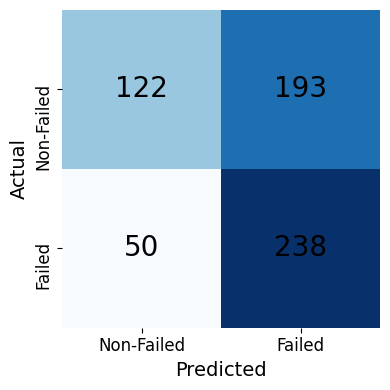

In [4]:
import matplotlib.pyplot as plt

# Dati
confusion_matrix = [[tn, fp], [fn, tp]]

plt.figure(figsize=(4, 4))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Tutti i numeri in nero
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion_matrix[i][j]), fontsize=20, color='black', ha='center', va='center')

tick_marks = [0, 1]
class_labels = ["Non-Failed", "Failed"]

plt.xticks(tick_marks, class_labels, fontsize=12)
plt.yticks(tick_marks, class_labels, fontsize=12, rotation=90)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)

plt.tight_layout()
plt.show()


##  EXT TEST

In [425]:
# Media semplice delle probabilità
ext_data['mean_prob'] = (ext_data['predicted_prob_dl'] + ext_data['predicted_prob_hhs']+ext_data['predicted_prob_com']) / 3

    # Predizione finale basata sulla media
ext_data['final_pred'] = (ext_data['mean_prob'] >= 0.5).astype(int)


In [426]:
from sklearn.metrics import confusion_matrix
 
# Calcolo metriche finali
y_true = ext_data['label']
y_pred = ext_data['final_pred']
y_prob = ext_data['mean_prob']

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
sensitivity = recall_score(y_true, y_pred)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

In [427]:
print(bal_acc)
print(f1)
print(auc)
print(sensitivity)
print(specificity)

0.5691454693045606
0.6152683295540439
0.6419601116305527
0.7307001795332136
0.4075907590759076


In [428]:
grouped_df = (
    ext_data.groupby('patient_id')
    .agg({
        'label': 'first',  # presuppone che la label sia la stessa per tutte le immagini del paziente
        'final_pred': lambda x: int((x == 1).any())  # 1 se almeno una predizione è positiva
    })
    .reset_index()
)

In [429]:
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score,
    f1_score, recall_score, roc_auc_score
)

y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

# Confusion matrix
cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

# Metriche
bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, y_pred_patient)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


Confusion Matrix (a livello paziente):
[[ 66 249]
 [ 27 261]]
Balanced Accuracy: 0.558
F1 Score: 0.654
Sensitivity: 0.906
Specificity: 0.210
AUC: 0.558


In [430]:
from sklearn.metrics import confusion_matrix

grouped_df = (
    ext_data.groupby('patient_id')
    .agg({
        'label': 'first',  # si assume che sia uguale per tutte le immagini del paziente
        'mean_prob': 'mean'  # media delle probabilità pesate
    })
    .reset_index()
)

# Applica soglia alla probabilità media
grouped_df['final_pred'] = (grouped_df['mean_prob'] >= 0.5).astype(int)

# Calcolo metriche
y_true_patient = grouped_df['label']
y_pred_patient = grouped_df['final_pred']

cm_patient = confusion_matrix(y_true_patient, y_pred_patient)
tn, fp, fn, tp = cm_patient.ravel()

bal_acc_patient = balanced_accuracy_score(y_true_patient, y_pred_patient)
f1_patient = f1_score(y_true_patient, y_pred_patient)
sensitivity_patient = recall_score(y_true_patient, y_pred_patient)
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_true_patient, grouped_df['mean_prob'])  # attenzione: usa mean_prob qui!

print("\n🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)")
print("Confusion Matrix:")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")


🧑‍⚕️ METRICHE A LIVELLO PAZIENTE (soft voting)
Confusion Matrix:
[[122 193]
 [ 50 238]]
Balanced Accuracy: 0.607
F1 Score: 0.662
Sensitivity: 0.826
Specificity: 0.387
AUC: 0.662
